# 이미지를 텍스트로 검색/생성 RAG

In [2]:
%pip install -Uq langchain langchain-openai langchain-chroma

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/6

In [10]:
#구글드라이브 연동
from google.colab import drive
drive.mount('/content/drive') # 내 구글 드라이브를 /content/drive 경로로 마운트

BASE_PATH = '/content/drive/Mydrive/05_multimodal_rag/'  # 기본작업경로 변수



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import os  # os 모듈을 import한다.
from google.colab import userdata  # Colab의 userdata 모듈을 import한다.

os.environ['LANGSMITH_TRACING'] = 'true'                             # LANGSMITH_TRACING 환경 변수를 설정한다.
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com' # LANGSMITH의 엔드포인트를 설정한다.
os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')  # LANGSMITH API 키를 환경 변수에 설정한다.
os.environ['LANGSMITH_PROJECT'] = 'skn23-multimodal-rag'             # LANGSMITH 프로젝트 이름을 설정한다.
os.environ['OPENAI_API_KEY'] = userdata.get("OPENAI_API_KEY")        # OpenAI API 키를 환경 변수에 설정한다.

## 이미지 캡셔닝 & 벡터 DB 저장

In [12]:
# 이미지 파일을 Base64 문자열로 변환하는 함수
import base64          # base64 모듈을 임포트
from PIL import Image  # PIL의 Image 모듈을 임포트

def image_to_base64(image_path):                          # 이미지 경로를 받아 Base64로 변환하는 함수 정의
  with open(image_path, 'rb') as f:                       # 이미지를 바이너리 모드로 열기
    encoded = base64.b64encode(f.read()).decode('utf-8')  # 파일 내용을 Base64로 인코딩 후 문자열로 디코드
  return encoded                                          # 인코딩된 문자열 반환

- 이렇게 인코딩된 문자열은 json의 값으로 보내면 이미지를 보낼때 매우 편하게 보낼 수 있다.

In [16]:
from openai import OpenAI  # OpenAI 라이브러리에서 OpenAI 클래스를 가져옴

client = OpenAI()  # OpenAI의 클라이언트 인스턴스를 생성

# 이미지 파일을 받아 안전교육 및 화재대피 관점에서 요약하는 함수
def summarize_image(image_path):  # 이미지 경로를 입력받는 함수 정의
  encoded = image_to_base64(image_path)  # 이미지를 Base64로 인코딩

  response = client.chat.completions.create(  # 대화형 응답을 생성하는 API 호출
      model = 'gpt-4.1-mini',  # 사용하는 모델 버전 지정
      messages = [  # 모델에 보낼 메시지 목록
            {
                'role': 'system',  # 시스템 역할 메시지
                'content': '''  # 시스템 메시지 내용을 시작
                아래 이미지를 안전교육 및 화재대피 관점에서  # 요약할 내용의 주제 지정
                주제문구와 각 장면에 대한 정보를 빠짐없이 한국어로 설명해주세요.  # 요청하는 형식과 언어 명시
                           '''  # 시스템 메시지 내용 끝
            },
            {
                'role': 'user',  # 사용자의 역할 메시지
                'content': [{  # 이미지 정보를 포함한 내용
                    'type': 'image_url',  # 이미지 입력 타입 지정
                    'image_url': {  # 이미지 URL 정보
                        'url': f'data:image/jpeg;base64,{encoded}'  # Base64 인코딩된 이미지 전달
                                 }  # 이미지 URL 정보 끝
                           }]  # 사용자 메시지 내용 끝
            }
        ],
    max_tokens = 1024
    )  # API 호출 끝
  return response.choices[0].message.content

print(summarize_image(f"/content/drive/MyDrive/05_multimodal_rag/figures/figure-1.jpg"))

주제: 완강기 사용법 - 화재 시 안전한 대피를 위한 절차

1. 후크를 고리에 안전하게 건다.
   - 안전하게 고리에 후크를 걸어 완강기 장치를 고정하는 단계입니다.

2. 리일(줄)을 창밖으로 던진다.
   - 대피 시 줄을 창밖으로 던져 외부로 통하는 길을 확보해야 합니다.

3. 벨트를 가슴에 안전하게 맨다.
   - 벨트를 단단히 가슴에 매어 몸을 안전하게 고정합니다.

4. 벽면을 안전하게 타고 내려간다.
   - 벽면을 마주보며 천천히 조심스럽게 아래로 내려가서 안전하게 대피합니다.

이 지침은 화재 상황에서 완강기를 효과적으로 사용하여 안전하게 탈출하는 방법을 단계별로 설명하고 있습니다.


In [17]:
from langchain_chroma.vectorstores import Chroma            # Chroma 모듈 가져오기
from langchain_openai import OpenAIEmbeddings               # OpenAI 임베딩 모듈 가져오기
from tqdm.auto import tqdm                                  # 진행률 표시줄 모듈 가져오기
import os                                                   # 운영 체제 관련 모듈 가져오기

persistent_dir = "/content/drive/MyDrive/05_multimodal_rag/chroma"  # 데이터 저장 경로 설정

embeddings = OpenAIEmbeddings(model= 'text-embedding-3-small')  # OpenAI 임베딩 모델 객체 생성
vector_db = Chroma(                                             # Chroma 인스턴스 생성
    collection_name= 'multimodal_rag',                          # 데이터베이스 컬렉션 이름 설정
    embedding_function= embeddings,                             # 임베딩 함수 지정
    persist_directory= persistent_dir                           # 데이터 저장 경로 지정
)

In [22]:
figure_dir = os.path.join('/content/drive/MyDrive/05_multimodal_rag', 'figures')  # 이미지의 폴더 경로

image_files = [
    os.path.join(figure_dir, filename)      # 전체 경로 저장
    for filename in os.listdir(figure_dir)  # 폴더 내 파일 목록 순회
    if filename.lower().endswith('.jpg')    # 확장자가 .jpg파일
]

for img_path in tqdm(image_files):
  b64_str = image_to_base64(img_path)       # 이미지 Base64 인코딩
  caption = summarize_image(img_path)       # 이미지 요약 생성
  vector_db.add_texts(
      texts= [caption],                     # 벡터화해서 저장
      metadatas = [
          {'base64_image' : b64_str,
           'image_path' : img_path}
          ]
  )

  0%|          | 0/3 [00:00<?, ?it/s]

In [23]:
docs = vector_db._collection.get()  # 컬렉션에 저장된 전체 문서 및 메타데이터

# 문서와 메타데이터를 함께 순회하면서 출력
for i, (page_content, metadata) in enumerate(zip(docs['documents'], docs['metadatas'])):
  print(f'[{i + 1}]')
  print(f'{page_content = }')
  print(f'{metadata = }')
  print()

[1]
page_content = '주제: 완강기 사용법 및 화재 시 안전한 대피 방법\n\n1. 후크를 고리에 안전하게 건다.\n   - 완강기의 후크를 견고한 고리에 안전하게 걸어 고정한다.\n2. 리일(줄)을 창밖으로 던진다.\n   - 완강기에서 나온 줄을 창문 바깥쪽으로 확실히 던져 고정시킨다.\n3. 벨트를 가슴에 안전하게 맨다.\n   - 완강기 벨트를 몸에 착용하여 안전하게 고정한다.\n4. 벽면을 안전하게 타고 내려간다.\n   - 벽을 마주 보며 몸을 안정적으로 조절하여 천천히 아래로 내려간다.\n\n해당 내용은 화재 등 위급상황 시 완강기를 이용해 안전하게 탈출하는 방법을 설명하며, 각 단계별로 그림과 함께 이해하기 쉽게 안내하고 있다.'
metadata = {'base64_image': '...', 'image_path': '/content/drive/MyDrive/05_multimodal_rag/figures/figure-1.jpg'}

[2]
page_content = '# 화재 대피용 완강기 사용 방법 안내\n\n1. 후크를 고리에 안전하게 건다.  \n   - 완강기의 후크를 건물 내 설치된 아이볼트(고리)에 단단히 걸어 고정한다.\n\n2. 리일(줄)을 창밖으로 던진다.  \n   - 완강기에 달린 줄을 창문 밖으로 잘 던져 바깥으로 늘어진 상태를 만든다.\n\n3. 벨트를 가슴에 안전하게 맨다.  \n   - 완강기 벨트를 가슴 쪽에 단단히 조여 몸에 고정한다.\n\n4. 벽면을 안전하게 타고 내려간다.  \n   - 몸을 벽 쪽으로 향하게 하여 서서히 안전하게 지상으로 하강한다.\n\n이 안내문은 화재 발생 시 높은 층에서 안전하게 외부로 대피할 수 있게 도와주는 완강기 사용법을 시각적으로 이해하기 쉽게 설명한 안전교육 자료입니다.'
metadata = {'base64_image': '...', 'image_path': '/content/drive/MyDrive/05_multimodal_rag/figures/figure-1.j

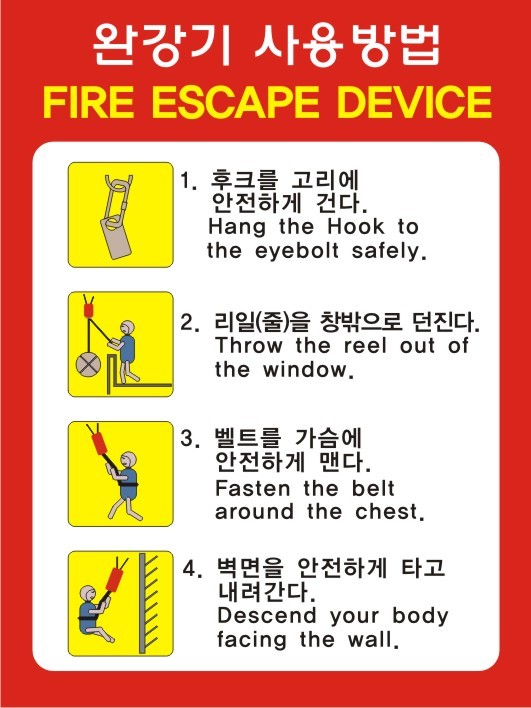

In [25]:
from io import BytesIO
from PIL import Image

# Base64 문자열 -> 이미지로 화면 출력하는 함수
def show_base64_image(b64_str):
  img = Image.open(BytesIO(base64.b64decode(b64_str)))
  display(img)

show_base64_image(docs['metadatas'][0]['base64_image'])

[1]
 아래는 이미지의 소방 교육 및 화재대피 관점에서의 요약입니다.

---

### 주제: 소방 교육 내용 및 화재대피 방법

1. **소화 (FIRE CONTROL)**  
   - 소화기 사용요령  
   - 옥내 소화전 사용요령  
   (화재 발생 시 초기 진화와 화재 확산 방지를 위한 소화기와 소화전 사용 방법 교육)

2. **통보 (FIRE CONTROL)**  
   - 화재 시 상황전파 및 비상대응 방법  
   (화재 발생 즉시 신속하게 상황을 알리고, 적절한 비상 대응 체계를 마련하는 방법 교육)

3. **피난 (FIRE CONTROL)**  
   - 화재 시 피난요령  
   - 피난 실패 시 행동요령  
   - 완강기 사용요령  
   (화재 시 신속하고 안전하게 건물을 대피하는 방법과 만약 대피에 실패했을 때의 대처법, 완강기 사용법 교육)

4. **응급처치 (FIRE CONTROL)**  
   - 심폐소생술  
   - 자동심장충격기 사용방법  
   (화재 현장에서 부상자 발생 시 기본적인 응급처치 및 생명 구조를 위한 심폐소생술과 자동심장충격기 사용법 교육)

---

소방 교육은 화재 발생 초기 대응부터 대피, 응급처치까지 폭넓게 다루어 화재 안전을 체계적으로 학습하도록 구성되어 있습니다.


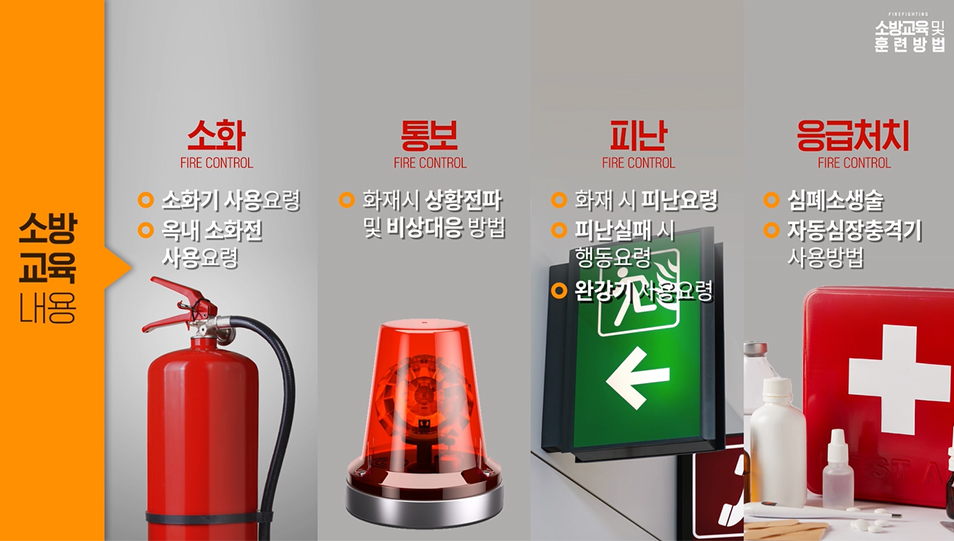

[2]
 # 불나면 대피먼저! - 화재대피 방법과 주의사항 안내

1. **화재대피방법**
   - **코와 입을 손수건 등으로 막는다:** 연기로부터 호흡기를 보호하기 위해 손수건으로 코와 입을 막아야 한다.
   - **자세를 낮춘다:** 연기가 위로 올라가므로 자세를 낮추어 연기를 피해 안전하게 대피한다.
   - **한 손으로는 벽을 잡는다:** 길을 잃지 않고 안전한 이동을 위해 한 손은 벽에 대고 대피한다.
   - **화살표 방향으로 신속히 대피한다:** 안내 표지판이나 비상구 표시를 따라 빠르게 밖으로 나간다.

2. **화재대피 시 주의사항**
   - **엘리베이터 절대 사용금지:** 화재 시 엘리베이터는 고장이나 연기 유입 위험이 있어 사용하면 안 된다.
   - **무섭다고 숨으면 안 된다:** 공포심에 숨지 말고 침착하게 신속히 대피해야 한다.

이 내용은 화재 시 안전하고 신속하게 대피하는 방법과 주의사항을 어린이들도 쉽게 이해할 수 있도록 설명하고 있으며, 인천남동소방서에서 제공한 자료임을 알 수 있다.


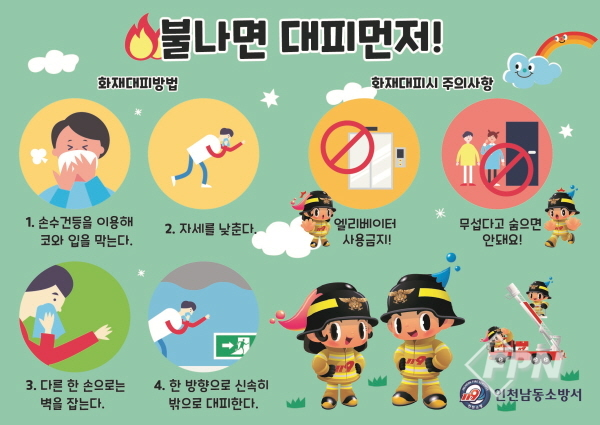

In [26]:
# 벡터 DB 유사도 검색 후 이미지 및 캡션 출력
query = '소화기 어떻게 써야돼?'
docs = vector_db.similarity_search(query, k=2)
for i, doc in enumerate(docs):
  print(f"[{i + 1}]\n {doc.page_content}")         # 해당 문서의 캡션(요약 내용)
  show_base64_image(doc.metadata['base64_image'])  # 메타데이터에 저장된 이미지 출력

## Multimodal RAG 구현
- agentic rag 구현(middleware 기반 검색된 문서 제공)
- text + image 응답

화재 시 안전하게 대피하기 위한 기본 요령은 다음과 같습니다:

1. **침착 유지**  
   당황하지 말고 침착하게 행동하세요.

2. **화재 경보 울리기**  
   화재를 발견하면 즉시 화재 경보를 작동시키고 주변 사람들에게 알리세요.

3. **빠른 대피**  
   연기와 불길을 피해 가장 가까운 대피로(비상구)를 이용해 신속하게 건물을 벗어나세요.

4. **저체온 및 연기 회피**  
   연기가 많을 경우 몸을 최대한 낮춰(무릎이나 엎드린 자세) 신선한 공기를 마시며 이동하세요. 젖은 천으로 코와 입을 막는 것도 도움이 됩니다.

5. **엘리베이터 사용 금지**  
   엘리베이터는 절대 사용하지 말고 계단으로 대피하세요.

6. **문 닫기**  
   대피 중인 방의 문은 닫아 연기와 불이 퍼지는 것을 막습니다.

7. **대피 후 신고**  
   안전한 장소에 도착하면 119에 신고하고, 다른 사람이 대피하는지 확인하세요.

8. **몸 상태 확인 및 응급처치**  
   화상이나 연기 흡입 등의 피해가 있으면 즉시 응급처치를 하고 의료기관을 방문하세요.

화재 시 평소에 대피로와 비상구 위치를 숙지하는 것도 매우 중요합니다.
[검색된내용]


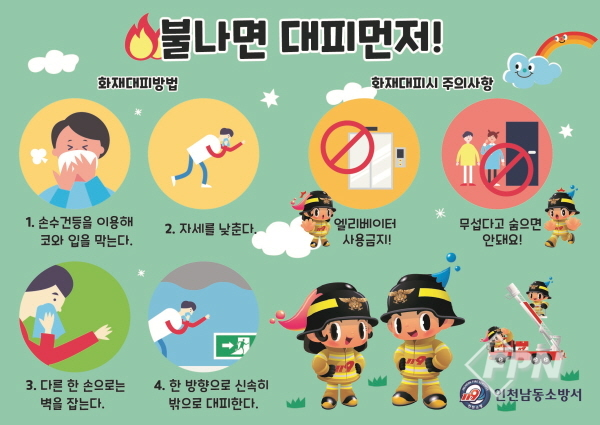

# 불나면 대피먼저! - 화재대피 방법과 주의사항 안내

1. **화재대피방법**
   - **코와 입을 손수건 등으로 막는다:** 연기로부터 호흡기를 보호하기 위해 손수건으로 코와 입을 막아야 한다.
   - **자세를 낮춘다:** 연기가 위로 올라가므로 자세를 낮추어 연기를 피해 안전하게 대피한다.
   - **한 손으로는 벽을 잡는다:** 길을 잃지 않고 안전한 이동을 위해 한 손은 벽에 대고 대피한다.
   - **화살표 방향으로 신속히 대피한다:** 안내 표지판이나 비상구 표시를 따라 빠르게 밖으로 나간다.

2. **화재대피 시 주의사항**
   - **엘리베이터 절대 사용금지:** 화재 시 엘리베이터는 고장이나 연기 유입 위험이 있어 사용하면 안 된다.
   - **무섭다고 숨으면 안 된다:** 공포심에 숨지 말고 침착하게 신속히 대피해야 한다.

이 내용은 화재 시 안전하고 신속하게 대피하는 방법과 주의사항을 어린이들도 쉽게 이해할 수 있도록 설명하고 있으며, 인천남동소방서에서 제공한 자료임을 알 수 있다.


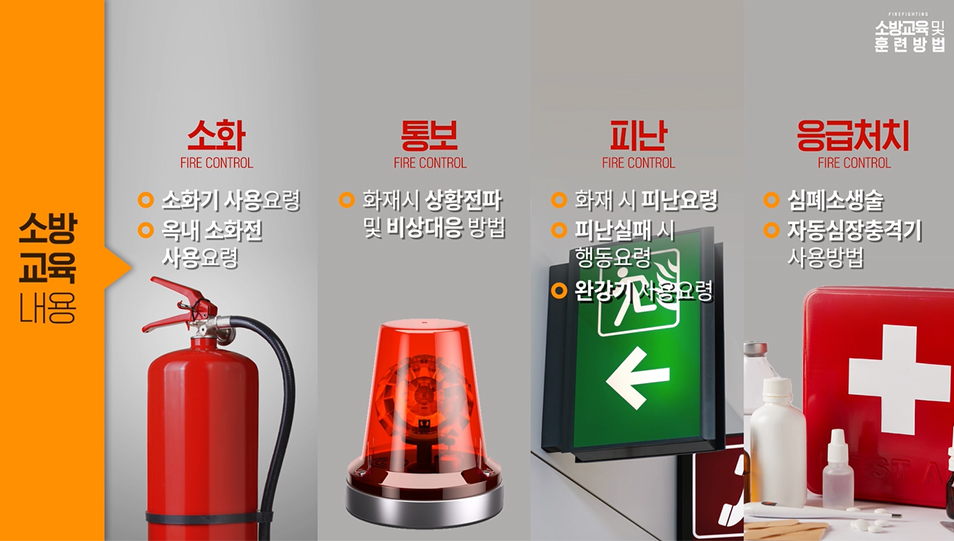

아래는 이미지의 소방 교육 및 화재대피 관점에서의 요약입니다.

---

### 주제: 소방 교육 내용 및 화재대피 방법

1. **소화 (FIRE CONTROL)**  
   - 소화기 사용요령  
   - 옥내 소화전 사용요령  
   (화재 발생 시 초기 진화와 화재 확산 방지를 위한 소화기와 소화전 사용 방법 교육)

2. **통보 (FIRE CONTROL)**  
   - 화재 시 상황전파 및 비상대응 방법  
   (화재 발생 즉시 신속하게 상황을 알리고, 적절한 비상 대응 체계를 마련하는 방법 교육)

3. **피난 (FIRE CONTROL)**  
   - 화재 시 피난요령  
   - 피난 실패 시 행동요령  
   - 완강기 사용요령  
   (화재 시 신속하고 안전하게 건물을 대피하는 방법과 만약 대피에 실패했을 때의 대처법, 완강기 사용법 교육)

4. **응급처치 (FIRE CONTROL)**  
   - 심폐소생술  
   - 자동심장충격기 사용방법  
   (화재 현장에서 부상자 발생 시 기본적인 응급처치 및 생명 구조를 위한 심폐소생술과 자동심장충격기 사용법 교육)

---

소방 교육은 화재 발생 초기 대응부터 대피, 응급처치까지 폭넓게 다루어 화재 안전을 체계적으로 학습하도록 구성되어 있습니다.


In [29]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain.agents.middleware import AgentMiddleware, AgentState # 에이전트 미들웨어 / 상태 타입
from langchain_core.documents import Document                       # 검색 결과 문서 타입
from typing import Any                                              # 타입 힌트용

# 에이전트가 유지할 상태 스키마 정의(검색 문서 컨텍스트 저장)
class State(AgentState):
  context: list['Document']

# 모델 호출 전 문서 검색 및 프롬프트 재작성하는 미들웨어
class RetrieveDocumentMiddleware(AgentMiddleware[State]):
  state_schema = State

  def before_model(self, state:AgentState) -> dict[str, Any] | None:
    last_message = state['messages'][-1]    # 유저 메시지
    retrieved_docs = vector_db.similarity_search(last_message.text, k=2)    # 사용제 메시지 질문과 유사한 문서 2개 검색

    docs_content = '\n\n'.join(doc.page_content for doc in retrieved_docs)  # 문서 본문을 하나의 문자열로 결합

    prompt = f"""
    제공된 '참조 문서'의 내용을 바탕으로 '사용자 질문'에 대해 상세히 답변하라.

    제약 조건:
    - 답변은 반드시 제공된 문서 내의 정보만을 근거로 작성한다.
    - 문서에서 답을 찾을 수 없는 경우, "제공된 정보에서는 해당 내용을 확인할 수 없습니다"라고 답변한다.
    - 논리적이고 가독성이 좋게 구조화하여 설명한다.

    참조 문서:
    {docs_content}

    사용자 질문:
    {last_message.text}
    """
    return {
          'messages' : [last_message.model_copy(update={'context' : prompt})],  # 사용자 메시지를 프롬프트로 바꿔 모델에 전달
          'context'  : retrieved_docs                                           # 검색된 문서를 상태에 저장
      }

llm = init_chat_model('openai:gpt-4.1-mini')
agent = create_agent(
  llm,
  tools = [],
  middleware = [RetrieveDocumentMiddleware()]   # 모델 호출 전 검색 / 프롬프트 주입 미들웨어
)

response = agent.invoke({'messages' : [
    ('human', '화재시 대피 요령은 어떻게 돼?')
    ]
})                        # 에이전트 실행 (미들웨어가 검색 후 프롬프트 변경하고 모델 호출)

print(response['messages'][-1].content) # 최종 모델 응답

print('[검색된내용]')
for doc in response['context']:                     # 검색된 문서들을 순회
  show_base64_image(doc.metadata['base64_image'])   # 이미지 출력
  print(doc.page_content)                           # 각 문서의 캡션(요약 텍스트)